# Analyse du NIST SP 800-90A (HMAC_DRBG)


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, kstest

# On suppose que la classe HMAC_DRBG est dans generators/hmac_drbg.py
sys.path.append(os.path.abspath('../generators'))
from hmac_drbg import HMAC_DRBG

# Initialisation avec une source d'entropie (ex: 32 octets)
entropy = os.urandom(32)
drbg = HMAC_DRBG(entropy)

# Génération de 50 000 octets
N = 50000
raw_bytes = drbg.generate(N)
data_drbg = list(raw_bytes)

print(f"Génération terminée : {len(data_drbg)} octets produits.")

Génération terminée : 50000 octets produits.


## 1. Distribution et Entropie
Nous vérifions l'uniformité visuelle et la densité d'information par octet.

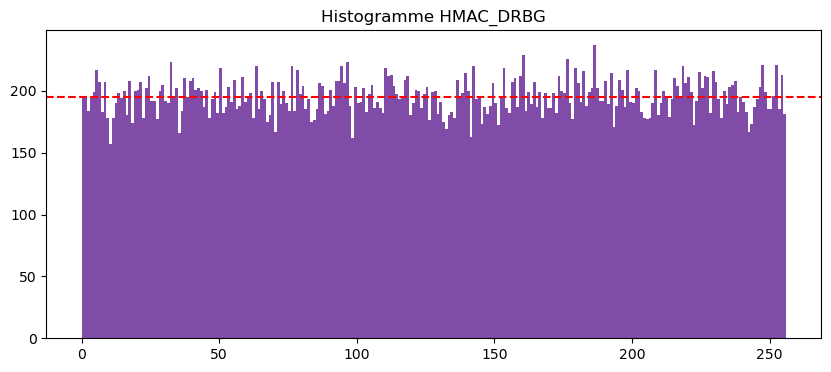

Entropie de Shannon : 7.996421 bits/octet


In [2]:
# Histogramme
plt.figure(figsize=(10, 4))
plt.hist(data_drbg, bins=256, range=(0, 256), color='indigo', alpha=0.7)
plt.axhline(y=N/256, color='red', linestyle='--')
plt.title("Histogramme HMAC_DRBG")
plt.show()

# Entropie
def shannon_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

print(f"Entropie de Shannon : {shannon_entropy(data_drbg):.6f} bits/octet")

## 2. Tests Statistiques : $\chi^2$ et Kolmogorov-Smirnov


In [3]:
# Chi-carré
obs, _ = np.histogram(data_drbg, bins=256, range=(0, 256))
chi2_stat, chi2_p = chisquare(obs)

# KS Test
data_norm = np.array(data_drbg) / 255.0
ks_stat, ks_p = kstest(data_norm, 'uniform')

print(f"Test Chi2 (p-value) : {chi2_p:.5f}")
print(f"Test KS (p-value) : {ks_p:.5f}")

Test Chi2 (p-value) : 0.61315
Test KS (p-value) : 0.06697


## 3. Analyse de l'Autocorrélation


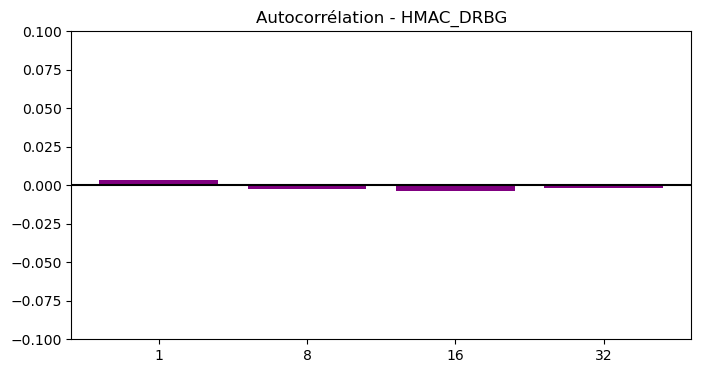

In [4]:
def plot_autocorr(data, lags=[1, 8, 16, 32]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    plt.figure(figsize=(8, 4))
    plt.bar([str(l) for l in lags], corrs, color='purple')
    plt.axhline(y=0, color='black')
    plt.ylim(-0.1, 0.1)
    plt.title("Autocorrélation - HMAC_DRBG")
    plt.show()

plot_autocorr(data_drbg)